# BeautifulSoup Documentation Analytics

Reproducible analysis companion for the final project.

## tl;dr

The pipeline converts one official Beautiful Soup documentation snapshot into section, link, and code-example datasets; answers ten analytical questions; and produces four required charts.

## Context & Methods

Source: https://www.crummy.com/software/BeautifulSoup/bs4/doc/.

### Key Assumptions

- Sections are delimited by h1, h2, and h3 headings.
- Code examples are represented by pre elements.
- Technical keywords use the curated vocabulary in `src/analyzer.py`.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))
from analyzer import (q1_total_sections, q2_highest_word_count_section, q3_most_code_examples_section, q4_most_links_section, q5_top10_keywords, q6_internal_external_links, q7_find_all_usage, q8_get_text_usage, q9_word_count_statistics, q10_bs4_method_usage_ratio)

## Data

### 1. Load and validate the three processed datasets

In [2]:
processed = PROJECT_ROOT / 'data' / 'processed'
sections_df = pd.read_csv(processed / 'sections.csv', encoding='utf-8-sig')
links_df = pd.read_csv(processed / 'links.csv', encoding='utf-8-sig')
code_df = pd.read_csv(processed / 'code_examples.csv', encoding='utf-8-sig')

datasets = {'sections': sections_df, 'links': links_df, 'code_examples': code_df}
assert all(not frame.isna().any().any() for frame in datasets.values())
pd.DataFrame([{'dataset': name, 'rows': len(frame), 'columns': len(frame.columns)} for name, frame in datasets.items()])

,dataset,rows,columns
0,sections,113,7
1,links,504,4
2,code_examples,220,9


## Results

### 2. Answer the eight required and two additional questions

In [3]:
results = {
    'Q1 Total sections': q1_total_sections(sections_df),
    'Q2 Highest word-count section': q2_highest_word_count_section(sections_df),
    'Q3 Most code examples': q3_most_code_examples_section(sections_df),
    'Q4 Most links': q4_most_links_section(sections_df),
    'Q5 Top technical keywords': q5_top10_keywords(sections_df),
    'Q6 Internal/external links': q6_internal_external_links(links_df),
    'Q7 find_all() usage': q7_find_all_usage(code_df),
    'Q8 get_text() usage': q8_get_text_usage(code_df),
    'Q9* Word-count statistics': q9_word_count_statistics(sections_df),
    'Q10* Search-method ratio': q10_bs4_method_usage_ratio(code_df),
}
pd.DataFrame([{'question': key, 'answer': value} for key, value in results.items()])

,question,answer
0,Q1 Total sections,113
1,Q2 Highest word-count section,"{'section_title': 'Multi-valued attributes', '..."
2,Q3 Most code examples,"{'section_title': 'Multi-valued attributes', '..."
3,Q4 Most links,"{'section_title': 'Table of Contents', 'link_c..."
4,Q5 Top technical keywords,"[{'keyword': 'soup', 'frequency': 516}, {'keyw..."
5,Q6 Internal/external links,"{'internal_anchor': 470, 'external_link': 19}"
6,Q7 find_all() usage,39
7,Q8 get_text() usage,4
8,Q9* Word-count statistics,"{'mean': 173.44247787610618, 'median': 139.0, ..."
9,Q10* Search-method ratio,"{'total_code_examples': 220, 'examples_using_s..."


### 3. Reproduce the four required charts

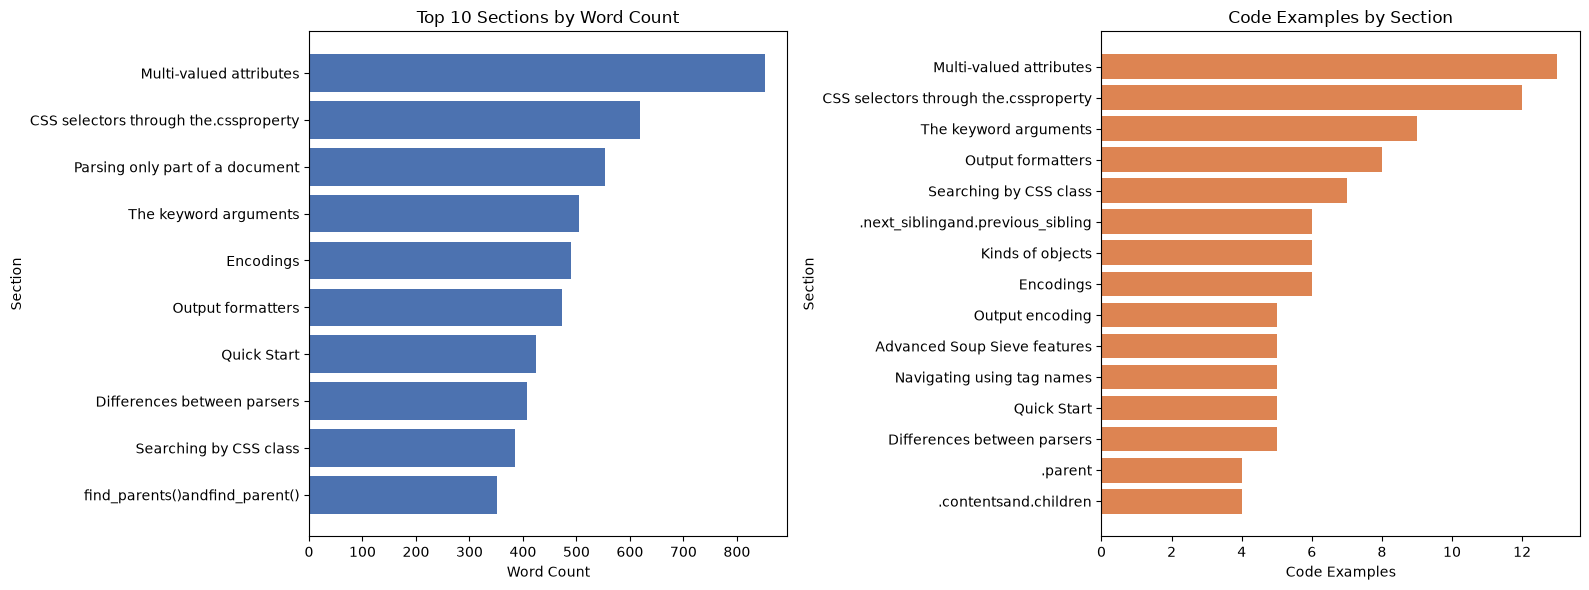

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
top_sections = sections_df.nlargest(10, 'word_count').sort_values('word_count')
axes[0].barh(top_sections['section_title'], top_sections['word_count'], color='#4C72B0')
axes[0].set(title='Top 10 Sections by Word Count', xlabel='Word Count', ylabel='Section')
code_counts = code_df.groupby('section_title').size().nlargest(15).sort_values()
axes[1].barh(code_counts.index, code_counts.values, color='#DD8452')
axes[1].set(title='Code Examples by Section', xlabel='Code Examples', ylabel='Section')
plt.tight_layout(); plt.show()

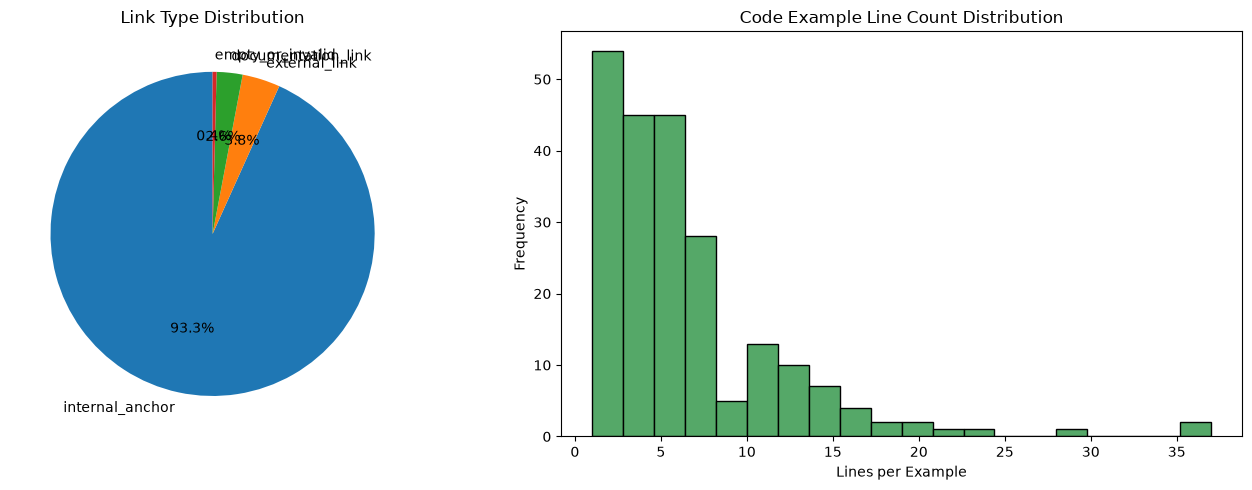

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
link_counts = links_df['link_type'].value_counts()
axes[0].pie(link_counts.values, labels=link_counts.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Link Type Distribution')
axes[1].hist(code_df['line_count'], bins=20, color='#55A868', edgecolor='black')
axes[1].set(title='Code Example Line Count Distribution', xlabel='Lines per Example', ylabel='Frequency')
plt.tight_layout(); plt.show()

## Takeaways

- The snapshot contains 113 sections, 504 links, and 220 code examples.
- Multi-valued attributes is the longest and most code-heavy section.
- Internal anchors dominate the link structure.
- Results describe one snapshot and may change when the source documentation is updated.